In [1]:
from google.colab import files

uploaded = files.upload()

Saving World-happiness-report-2024.csv to World-happiness-report-2024.csv


In [2]:
import pandas as pd

df = pd.read_csv("World-happiness-report-2024.csv")

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,Country name,Regional indicator,Ladder score,upperwhisker,lowerwhisker,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.741,7.815,7.667,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,Denmark,Western Europe,7.583,7.665,7.500,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,Western Europe,7.525,7.618,7.433,1.881,1.617,0.718,0.819,0.258,0.182,2.050
3,Sweden,Western Europe,7.344,7.422,7.267,1.878,1.501,0.724,0.838,0.221,0.524,1.658
4,Israel,Middle East and North Africa,7.341,7.405,7.277,1.803,1.513,0.740,0.641,0.153,0.193,2.298


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
#check dataset shape
print("Number of rows and columns:", df.shape)

Number of rows and columns: (143, 12)


In [5]:
#check column names
df.columns.tolist()

['Country name',
 'Regional indicator',
 'Ladder score',
 'upperwhisker',
 'lowerwhisker',
 'Log GDP per capita',
 'Social support',
 'Healthy life expectancy',
 'Freedom to make life choices',
 'Generosity',
 'Perceptions of corruption',
 'Dystopia + residual']

In [6]:
#dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country name                  143 non-null    object 
 1   Regional indicator            143 non-null    object 
 2   Ladder score                  143 non-null    float64
 3   upperwhisker                  143 non-null    float64
 4   lowerwhisker                  143 non-null    float64
 5   Log GDP per capita            140 non-null    float64
 6   Social support                140 non-null    float64
 7   Healthy life expectancy       140 non-null    float64
 8   Freedom to make life choices  140 non-null    float64
 9   Generosity                    140 non-null    float64
 10  Perceptions of corruption     140 non-null    float64
 11  Dystopia + residual           140 non-null    float64
dtypes: float64(10), object(2)
memory usage: 13.5+ KB


In [7]:
#check missing values
df.isnull().sum()

,0
Country name,0
Regional indicator,0
Ladder score,0
upperwhisker,0
lowerwhisker,0
Log GDP per capita,3
Social support,3
Healthy life expectancy,3
Freedom to make life choices,3
Generosity,3


In [8]:
#check dupliacte rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


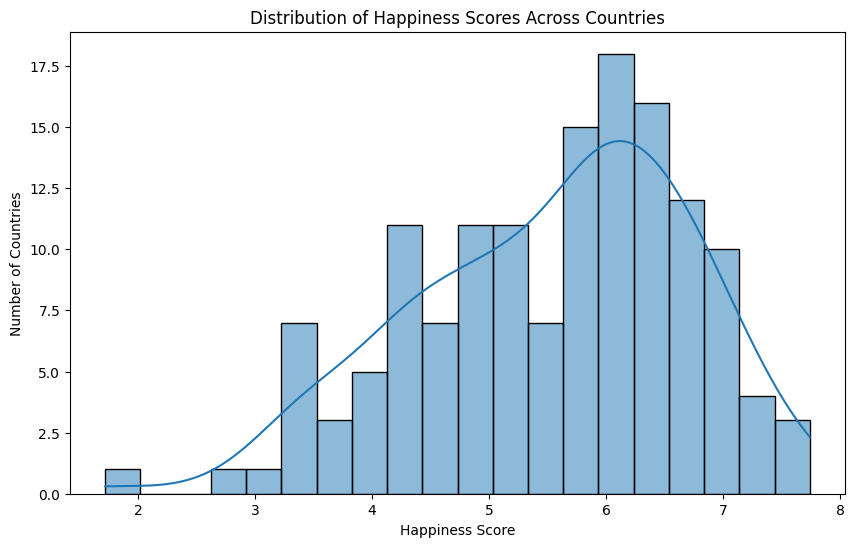

In [9]:
#Distribution of Happiness Scores
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Ladder score",
    bins=20,
    kde=True
)

plt.title("Distribution of Happiness Scores Across Countries")
plt.xlabel("Happiness Score")
plt.ylabel("Number of Countries")

plt.show()

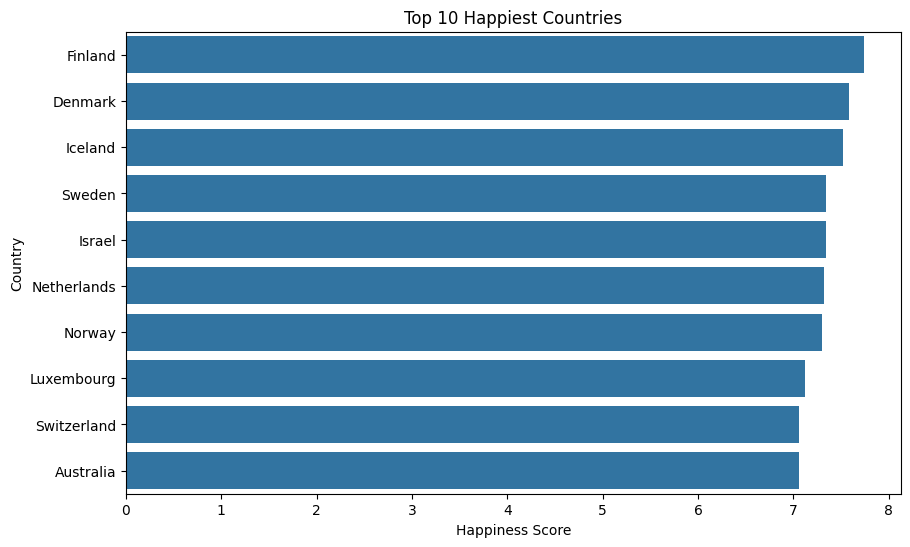

In [10]:
#Top 10 Happiest Countries
top_10 = df.nlargest(10, "Ladder score")

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10,
    x="Ladder score",
    y="Country name"
)

plt.title("Top 10 Happiest Countries")
plt.xlabel("Happiness Score")
plt.ylabel("Country")

plt.show()

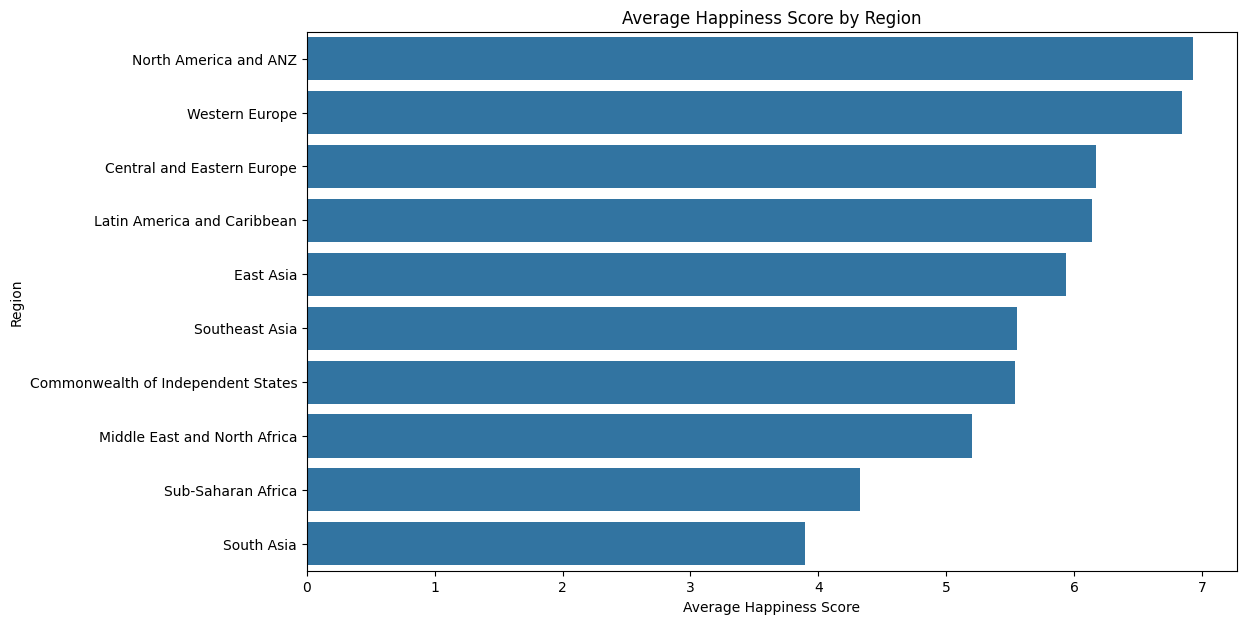

In [11]:
#Average Happiness by Region
region_happiness = (
    df.groupby("Regional indicator")["Ladder score"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=region_happiness.values,
    y=region_happiness.index
)

plt.title("Average Happiness Score by Region")
plt.xlabel("Average Happiness Score")
plt.ylabel("Region")

plt.show()

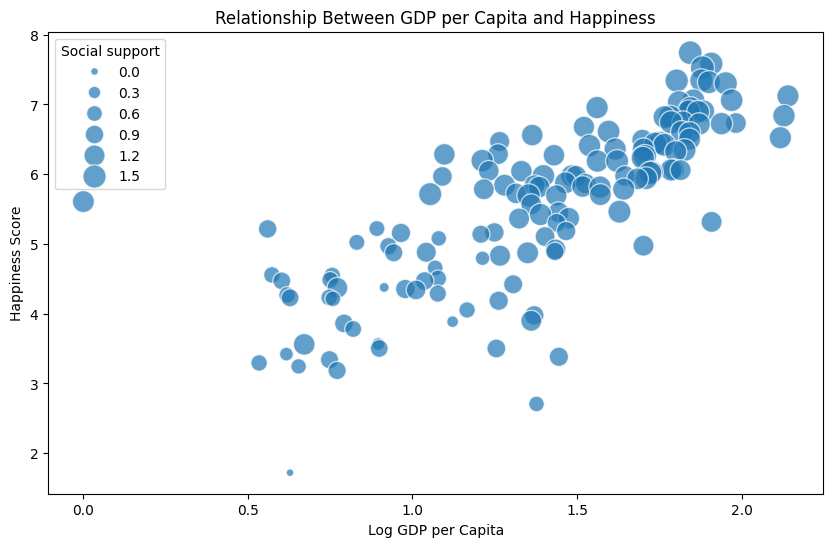

In [12]:
#GDP vs Happiness
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Log GDP per capita",
    y="Ladder score",
    size="Social support",
    sizes=(30, 300),
    alpha=0.7
)

plt.title("Relationship Between GDP per Capita and Happiness")
plt.xlabel("Log GDP per Capita")
plt.ylabel("Happiness Score")

plt.show()

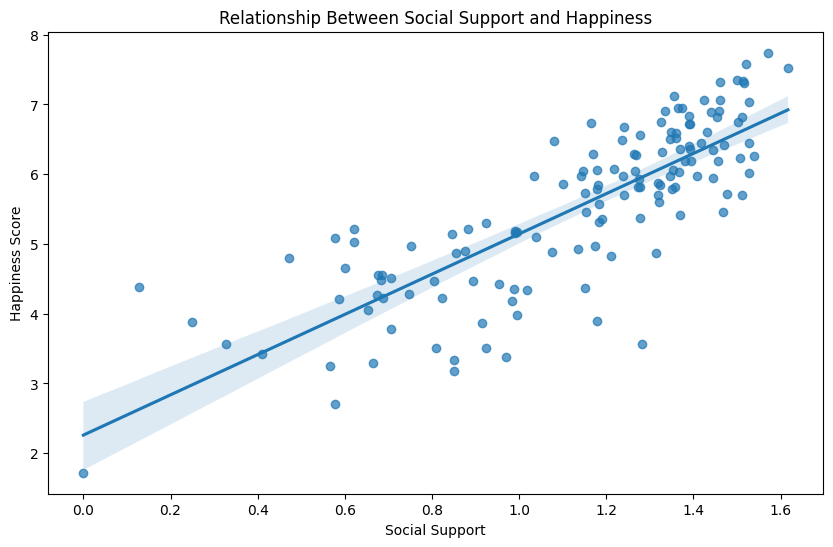

In [13]:
#Social Support vs Happiness
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x="Social support",
    y="Ladder score",
    scatter_kws={"alpha": 0.7}
)

plt.title("Relationship Between Social Support and Happiness")
plt.xlabel("Social Support")
plt.ylabel("Happiness Score")

plt.show()

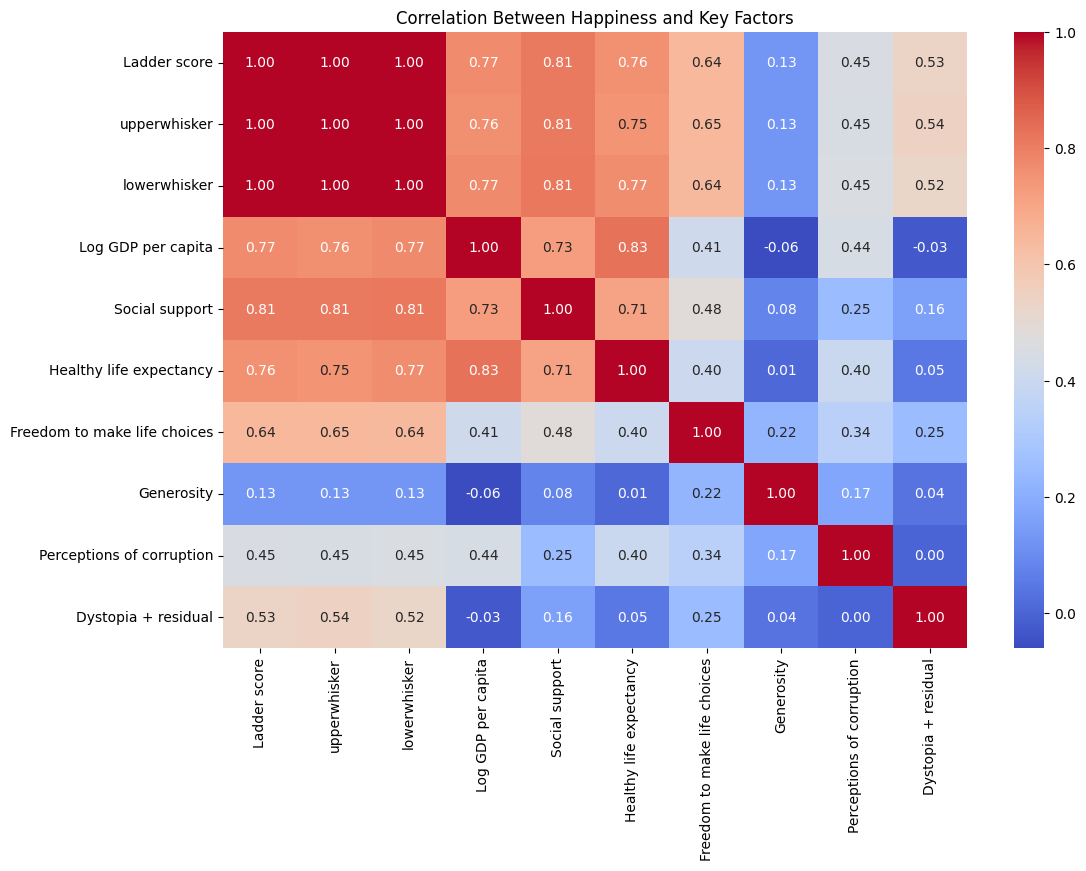

In [14]:
#Correlation Heatmap
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Happiness and Key Factors")

plt.show()

In [16]:
# Check missing values in the columns used for Plotly
df[["Log GDP per capita", "Ladder score", "Social support"]].isnull().sum()

,0
Log GDP per capita,3
Ladder score,0
Social support,3


In [17]:
df["Social support"] = df["Social support"].fillna(
    df["Social support"].median()
)

In [18]:
# Interactive Plotly Visualization

fig = px.scatter(
    df,
    x="Log GDP per capita",
    y="Ladder score",
    color="Regional indicator",
    hover_name="Country name",
    size="Social support",
    title="Interactive View: GDP, Social Support and Happiness"
)

fig.show()

In [19]:
# Calculate correlation with Happiness Score

numeric_df = df.select_dtypes(include="number")

correlation = numeric_df.corr()["Ladder score"].sort_values(ascending=False)

print("Factors Most Related to Happiness:")
print(correlation)

Factors Most Related to Happiness:
Ladder score                    1.000000
lowerwhisker                    0.999697
upperwhisker                    0.999678
Social support                  0.810450
Log GDP per capita              0.768504
Healthy life expectancy         0.759659
Freedom to make life choices    0.644451
Dystopia + residual             0.533542
Perceptions of corruption       0.451829
Generosity                      0.130038
Name: Ladder score, dtype: float64
